# 05 — Quality & Outliers

Formal QC: channel SNR, trial outliers, autocorrelation. Flags participants/channels/trials for exclusion or downweighting in BOCPD.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats

ROOT = Path.cwd() if (Path.cwd() / "data").exists() else (Path.cwd() / ".." / "..").resolve()
DATA_ROOT = ROOT / "data"
ARTIFACTS_DIR = ROOT / "artifacts" / "figures" / "quality_outliers"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
PARTICIPANTS = [f"sub-{i:02d}" for i in range(1, 11)]
DATE_TAG = "2026-02-25"
FS = 100

In [2]:
def load_preprocessed(path):
    d = np.load(path, allow_pickle=True).item()
    return d["preprocessed_eeg_data"], d["ch_names"], d["times"]

## 1. Channel SNR (signal vs baseline noise)

SNR = post-stimulus variance / baseline variance. Higher = more signal relative to pre-stimulus noise.

In [3]:
times_ms = np.linspace(-200, 790, 100)
baseline_mask = (times_ms >= -200) & (times_ms < 0)
post_mask = (times_ms >= 0) & (times_ms <= 800)

snr_rows = []
for sub in PARTICIPANTS:
    p = DATA_ROOT / sub / "preprocessed_eeg_training.npy"
    if not p.exists():
        continue
    X, ch_names, _ = load_preprocessed(p)
    for ch_idx, ch in enumerate(ch_names):
        x_ch = X[:, :, ch_idx, :]
        var_baseline = x_ch[:, :, baseline_mask].var()
        var_post = x_ch[:, :, post_mask].var()
        snr = var_post / (var_baseline + 1e-10)
        snr_rows.append({"participant": sub, "channel": ch, "snr": snr, "var_baseline": var_baseline, "var_post": var_post})

snr_df = pd.DataFrame(snr_rows)

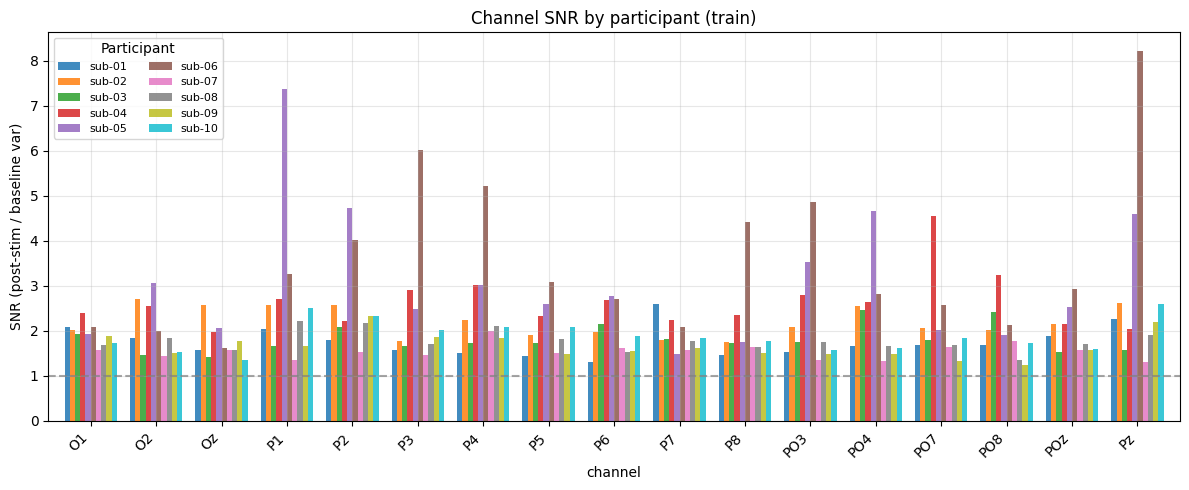

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))
pivot = snr_df.pivot(index="channel", columns="participant", values="snr")
pivot.plot(kind="bar", ax=ax, width=0.8, alpha=0.85)
ax.axhline(1, color="gray", ls="--", alpha=0.7)
ax.set_ylabel("SNR (post-stim / baseline var)")
ax.set_title("Channel SNR by participant (train)")
ax.legend(title="Participant", ncol=2, fontsize=8)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / f"quality__channel_snr__{DATE_TAG}.png", dpi=200, bbox_inches="tight")
plt.show()

## 2. Trial outliers (amplitude extremes)

Per trial: max absolute amplitude (channel-avg). Flag trials > 3 SD from participant mean.

In [5]:
outlier_rows = []
for sub in PARTICIPANTS:
    p = DATA_ROOT / sub / "preprocessed_eeg_training.npy"
    if not p.exists():
        continue
    X, ch_names, _ = load_preprocessed(p)
    ch_avg = X.mean(axis=2)
    max_amp = np.abs(ch_avg).max(axis=2)
    flat = max_amp.ravel()
    mean_amp, std_amp = flat.mean(), flat.std()
    n_out = (np.abs(flat - mean_amp) > 3 * std_amp).sum()
    pct = 100 * n_out / len(flat)
    outlier_rows.append({
        "participant": sub,
        "n_trials": len(flat),
        "n_outliers_3sd": n_out,
        "pct_outliers": pct,
        "mean_max_amp": mean_amp,
        "std_max_amp": std_amp,
    })

outlier_df = pd.DataFrame(outlier_rows)
tables_dir = ROOT / "artifacts" / "tables"
tables_dir.mkdir(parents=True, exist_ok=True)
outlier_df.to_csv(tables_dir / f"quality__trial_outliers__{DATE_TAG}.csv", index=False)
print(outlier_df.to_string(index=False))

participant  n_trials  n_outliers_3sd  pct_outliers  mean_max_amp  std_max_amp
     sub-01     66160             955      1.443470      0.771993     0.221927
     sub-02     66160             601      0.908404      0.783388     0.215461
     sub-03     66160            1430      2.161427      0.817645     0.381405
     sub-04     66160            2093      3.163543      0.776747     0.385526
     sub-05     66160             724      1.094317      0.749148     0.230171
     sub-06     66160             730      1.103386      0.720402     0.202997
     sub-07     66160             779      1.177449      0.780283     0.230063
     sub-08     66160            1188      1.795647      0.813009     0.365539
     sub-09     66160            1727      2.610339      0.753558     0.312335
     sub-10     66160             713      1.077690      0.747554     0.212697


## 3. Autocorrelation within epoch

For BOCPD we assume observations are conditionally independent. Check lag-1 autocorrelation of channel-averaged signal over time (per trial, then average).

In [6]:
n_sample = 500
acf_rows = []
for sub in PARTICIPANTS:
    p = DATA_ROOT / sub / "preprocessed_eeg_training.npy"
    if not p.exists():
        continue
    X, ch_names, _ = load_preprocessed(p)
    ch_avg = X.mean(axis=2)
    conds = np.random.choice(ch_avg.shape[0], size=min(n_sample, ch_avg.shape[0]), replace=False)
    reps = np.random.choice(ch_avg.shape[1], size=min(4, ch_avg.shape[1]), replace=True)
    acf_vals = []
    for c in conds:
        for r in reps:
            ts = ch_avg[c, r, :]
            ts = ts - ts.mean()
            if ts.var() < 1e-10:
                continue
            acf1 = np.corrcoef(ts[:-1], ts[1:])[0, 1]
            acf_vals.append(acf1)
    acf_mean = np.mean(acf_vals) if acf_vals else np.nan
    acf_std = np.std(acf_vals) if acf_vals else np.nan
    acf_rows.append({"participant": sub, "acf_lag1_mean": acf_mean, "acf_lag1_std": acf_std, "n_trials": len(acf_vals)})

acf_df = pd.DataFrame(acf_rows)
acf_df.to_csv(tables_dir / f"quality__autocorrelation__{DATE_TAG}.csv", index=False)
print(acf_df.to_string(index=False))

participant  acf_lag1_mean  acf_lag1_std  n_trials
     sub-01       0.822056      0.049661      2000
     sub-02       0.724776      0.082381      2000
     sub-03       0.745581      0.091393      2000
     sub-04       0.822243      0.072488      2000
     sub-05       0.795493      0.074791      2000
     sub-06       0.787728      0.085173      2000
     sub-07       0.744385      0.066283      2000
     sub-08       0.822305      0.061305      2000
     sub-09       0.804236      0.066487      2000
     sub-10       0.794098      0.081889      2000


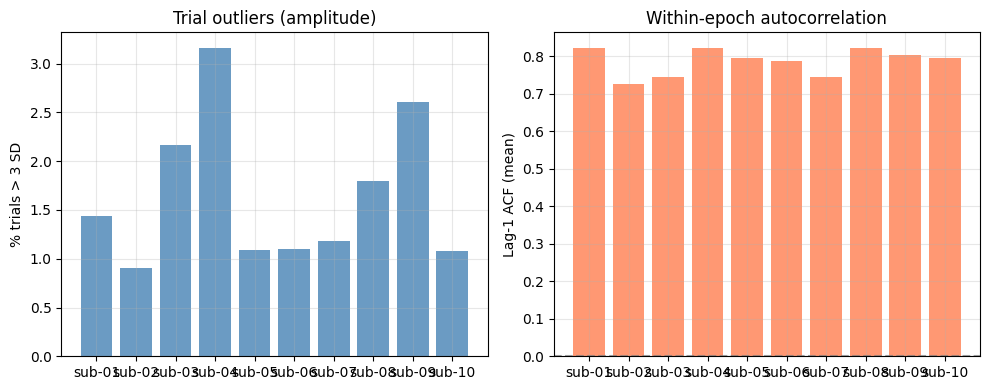

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(range(len(PARTICIPANTS)), outlier_df["pct_outliers"], color="steelblue", alpha=0.8)
axes[0].set_xticks(range(len(PARTICIPANTS)))
axes[0].set_xticklabels(PARTICIPANTS)
axes[0].set_ylabel("% trials > 3 SD")
axes[0].set_title("Trial outliers (amplitude)")
axes[0].grid(True, alpha=0.3)

axes[1].bar(range(len(PARTICIPANTS)), acf_df["acf_lag1_mean"], color="coral", alpha=0.8)
axes[1].set_xticks(range(len(PARTICIPANTS)))
axes[1].set_xticklabels(PARTICIPANTS)
axes[1].set_ylabel("Lag-1 ACF (mean)")
axes[1].set_title("Within-epoch autocorrelation")
axes[1].axhline(0, color="gray", ls="--", alpha=0.7)
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / f"quality__outliers_acf__{DATE_TAG}.png", dpi=200, bbox_inches="tight")
plt.show()

## 4. QC summary (flag participants from prior EDA)

Consolidate: sub-01, sub-04 (value range; trial variance); low-SNR channels; high outlier %.

In [8]:
snr_summary = snr_df.groupby("participant")["snr"].agg(["mean", "min", "std"]).reset_index()
snr_summary.columns = ["participant", "snr_mean", "snr_min", "snr_std"]
qc = outlier_df.merge(acf_df, on="participant").merge(snr_summary, on="participant")
qc["flag_value_range"] = qc["participant"].isin(["sub-01", "sub-04"])
qc["flag_high_outliers"] = qc["pct_outliers"] > 1
qc["flag_low_snr"] = qc["snr_mean"] < 1
qc.to_csv(tables_dir / f"quality__qc_summary__{DATE_TAG}.csv", index=False)
print(qc[["participant", "pct_outliers", "acf_lag1_mean", "snr_mean", "flag_value_range", "flag_high_outliers", "flag_low_snr"]].to_string(index=False))

participant  pct_outliers  acf_lag1_mean  snr_mean  flag_value_range  flag_high_outliers  flag_low_snr
     sub-01      1.443470       0.822056  1.763153              True                True         False
     sub-02      0.908404       0.724776  2.199709             False               False         False
     sub-03      2.161427       0.745581  1.817323             False                True         False
     sub-04      3.163543       0.822243  2.637419              True                True         False
     sub-05      1.094317       0.795493  3.090702             False                True         False
     sub-06      1.103386       0.787728  3.531911             False                True         False
     sub-07      1.177449       0.744385  1.544662             False                True         False
     sub-08      1.795647       0.822305  1.774745             False                True         False
     sub-09      2.610339       0.804236  1.670835             False     